# 📐 Filtragem Espacial - Convolução e Filtros Lineares

## 📖 Visão Geral

Este notebook explora a **filtragem espacial** - uma das operações fundamentais em processamento de imagens que permite transformar imagens através de operações de vizinhança local.

### 🎯 **Objetivos de Aprendizado:**
- Compreender a **convolução 2D** e sua implementação manual
- Dominar **filtros de suavização** (média, gaussiano)
- Aplicar **filtros de aguçamento** (Sobel, Prewitt, Laplaciano)
- Entender **operadores de gradiente** para detecção de bordas
- Implementar **unsharp masking** para realce de detalhes

### 🧪 **Experimentos Incluídos:**
- Implementação manual de convolução 2D
- Comparação de filtros de suavização
- Detecção de bordas com operadores de gradiente
- Aguçamento de imagens
- Análise de efeitos e parâmetros

---

In [1]:
# 📦 Setup e Importações
import sys
import os

# --- Configuração do Path ---
print(f"Diretório de trabalho atual: {os.getcwd()}")
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))
print(f"Raiz do projeto: {project_root}")

# Adiciona a raiz do projeto ao path do Python
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Importações ---
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import warnings
warnings.filterwarnings('ignore')

# Importa nossa biblioteca personalizada
try:
    from cv_lib import processamento
    from cv_lib.filtragem import espacial
    print("✅ Biblioteca 'cv_lib' importada com sucesso!")
    print("✅ Módulo 'cv_lib.filtragem.espacial' importado!")
    print("   • Funções disponíveis: convolucao_2d, filtro_gaussiano, filtro_sobel, etc.")
except ImportError as e:
    print(f"❌ Erro ao importar biblioteca: {e}")

print("\n📐 Notebook de Filtragem Espacial configurado e pronto!")
print("-" * 50)

Diretório de trabalho atual: e:\Personal Projects\Mestrado\ESTUDO CV\Estudo em Python\estudos_cv\notebooks\01 - Fundamentos de Processamento de Imagens
Raiz do projeto: e:\Personal Projects\Mestrado\ESTUDO CV\Estudo em Python\estudos_cv
✅ Biblioteca 'cv_lib' importada com sucesso!
✅ Módulo 'cv_lib.filtragem.espacial' importado!
   • Funções disponíveis: convolucao_2d, filtro_gaussiano, filtro_sobel, etc.

📐 Notebook de Filtragem Espacial configurado e pronto!
--------------------------------------------------


## 5.1 Fundamentos Teóricos da Convolução 2D

### 📚 **Fundamentação Acadêmica:**

> **Gonzalez & Woods, Digital Image Processing 4e, Eq.3-35, p.159:**  
> "(w ⊛ f)(x,y) = Σ Σ w(s,t) f(x-s, y-t)"  
> "This equation implements the sum of products process to which we refer throughout the book as **linear spatial filtering**"

> **Gonzalez & Woods, p.159:**  
> "Linear spatial filtering and spatial convolution are synonymous"

### 🧮 **Definição Matemática:**

#### **Convolução 2D (Gonzalez & Woods Eq.3-35):**
```
(w ⊛ f)(x,y) = Σ(s=-a to a) Σ(t=-b to b) w(s,t) × f(x-s, y-t)
```
Onde:
- `w(s,t)` = kernel/máscara de tamanho (2a+1) × (2b+1)
- `f(x,y)` = imagem de entrada
- **Kernel é rotacionado 180°** antes da operação

#### **Correlação vs Convolução:**

**Correlação (Eq.3-34):**
```
(w ⊙ f)(x,y) = Σ Σ w(s,t) × f(x+s, y+t)    [sem rotação]
```

**Convolução (Eq.3-35):**
```
(w ⊛ f)(x,y) = Σ Σ w(s,t) × f(x-s, y-t)    [com rotação 180°]
```

**Diferença:** O sinal negativo alinha as coordenadas quando o kernel é rotacionado.

### 🎯 **Aplicações Acadêmicas Citadas:**
**📚 Referência:** Gonzalez & Woods p.159-196
- **Smoothing/Blurring**: "Reduce noise and blur image details"
- **Sharpening**: "Enhance edges and fine details"
- **Edge Detection**: "Detect intensity transitions"
- **Feature Extraction**: "Extract local image features"

### 🔢 **Tipos de Padding (G&W p.160):**
- **'same'**: Mantém tamanho original (adiciona padding)
- **'valid'**: Apenas pixels válidos (reduz tamanho)
- **Modos de borda**: reflect, constant, edge, wrap

### ⚠️ **Propriedades Importantes:**
- **Comutatividade**: w ⊛ f = f ⊛ w
- **Associatividade**: (w₁ ⊛ w₂) ⊛ f = w₁ ⊛ (w₂ ⊛ f)
- **Distributividade**: (w₁ + w₂) ⊛ f = (w₁ ⊛ f) + (w₂ ⊛ f)

---

## 5.2 Implementação Manual da Convolução 2D

### 🔬 **Objetivo Pedagógico:**
Implementar convolução 2D manualmente para compreender o algoritmo básico.

### 📊 **Algoritmo (Gonzalez & Woods p.159):**
1. **Rotacionar** kernel 180° (diferença da correlação)
2. **Adicionar padding** se necessário
3. **Para cada pixel** (x,y):
   - Posicionar centro do kernel em (x,y)
   - Multiplicar elementos correspondentes
   - Somar produtos → valor de saída

📐 Demonstração de Convolução 2D (Gonzalez & Woods Eq.3-35)
Imagem de entrada (5×5):
[[ 10  10  10  10  10]
 [ 10  50  50  50  10]
 [ 10  50 100  50  10]
 [ 10  50  50  50  10]
 [ 10  10  10  10  10]]

Kernel (3×3) - Detecção de bordas verticais:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Resultado da convolução (mesmas dimensões):
[[   0  -80    0   80    0]
 [   0 -130    0  130    0]
 [   0 -170    0  170    0]
 [   0 -130    0  130    0]
 [   0  -80    0   80    0]]


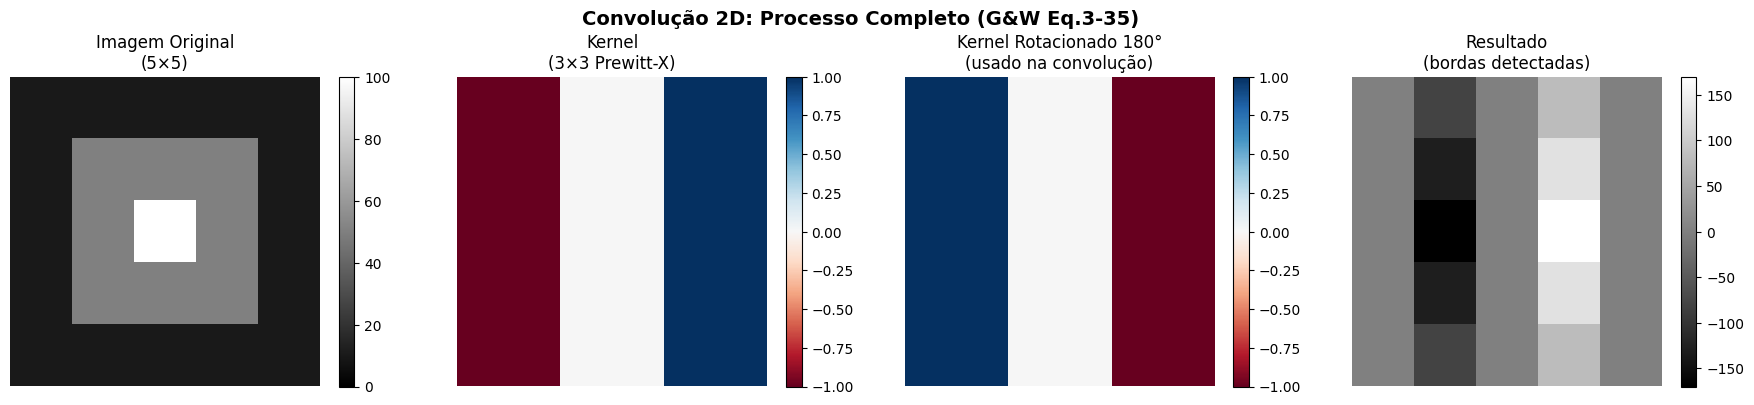


💡 Observações:
• Kernel rotacionado 180° antes da operação (diferença da correlação)
• Valores positivos = borda da esquerda para direita
• Valores negativos = borda da direita para esquerda
• Zeros = regiões sem transição horizontal


In [2]:
# 🔬 EXPERIMENTO: Demonstração Visual da Convolução 2D

print("📐 Demonstração de Convolução 2D (Gonzalez & Woods Eq.3-35)")
print("=" * 70)

# Cria imagem simples para demonstração
img_simples = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 100, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float64)

# Kernel de detecção de bordas horizontal
kernel_bordas = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float64)

print("Imagem de entrada (5×5):")
print(img_simples.astype(int))
print(f"\nKernel (3×3) - Detecção de bordas verticais:")
print(kernel_bordas.astype(int))

# Aplica convolução usando nossa implementação
resultado = espacial.convolucao_2d(img_simples, kernel_bordas, padding='same')

print(f"\nResultado da convolução (mesmas dimensões):")
print(resultado.astype(int))

# Visualização
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Imagem original
im0 = axes[0].imshow(img_simples, cmap='gray', vmin=0, vmax=100)
axes[0].set_title("Imagem Original\n(5×5)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Kernel
im1 = axes[1].imshow(kernel_bordas, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title("Kernel\n(3×3 Prewitt-X)")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Kernel rotacionado (usado na convolução)
kernel_rot = np.rot90(kernel_bordas, 2)
im2 = axes[2].imshow(kernel_rot, cmap='RdBu', vmin=-1, vmax=1)
axes[2].set_title("Kernel Rotacionado 180°\n(usado na convolução)")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# Resultado
im3 = axes[3].imshow(resultado, cmap='gray')
axes[3].set_title("Resultado\n(bordas detectadas)")
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.suptitle("Convolução 2D: Processo Completo (G&W Eq.3-35)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Observações:")
print("• Kernel rotacionado 180° antes da operação (diferença da correlação)")
print("• Valores positivos = borda da esquerda para direita")
print("• Valores negativos = borda da direita para esquerda")
print("• Zeros = regiões sem transição horizontal")

## 5.3 Filtros de Suavização (Lowpass)

### 📚 **Fundamentação Teórica:**

> **Gonzalez & Woods, Seção 3.5, p.167:**  
> "Smoothing filters are used for blurring and noise reduction"

> **Gonzalez & Woods, Eq.3-45, p.169:**  
> "Gaussian kernels: G(s,t) = K × e^(-(s²+t²)/(2σ²))"  
> "Gaussian kernels are the only circularly symmetric kernels that are also separable"

### 🧮 **Definições Matemáticas:**

#### **1. Filtro de Média (Box Filter):**
```
w(s,t) = 1/(m×n)  para todo (s,t)
```
Kernel 3×3:
```
1/9 × [1 1 1]
      [1 1 1]
      [1 1 1]
```

#### **2. Filtro Gaussiano (G&W Eq.3-45):**
```
G(s,t) = K × e^(-(s² + t²)/(2σ²))
```
Onde:
- `σ` = desvio padrão (controla largura da gaussiana)
- `K` = constante de normalização (Σ G = 1)
- Circularmente simétrico (isotrópico)

### 🎯 **Aplicações (G&W p.167-173):**
- **Redução de ruído**: Remove ruído gaussiano
- **Blur/Desfoque**: Suavização de imagens
- **Pré-processamento**: Antes de operações subsequentes

### 🔢 **Parâmetros Típicos:**
- **Box filter**: 3×3 a 11×11
- **Gaussiano σ**: 0.5 (leve) a 5.0 (forte)

---

📊 Comparação: Filtro de Média vs Gaussiano
📚 Referência: Gonzalez & Woods Seção 3.5, p.167-173
Imagem: (512, 512)

Kernels criados:
• Box filter 5×5 (média uniforme)
• Gaussiano 5×5 (σ=1.0)


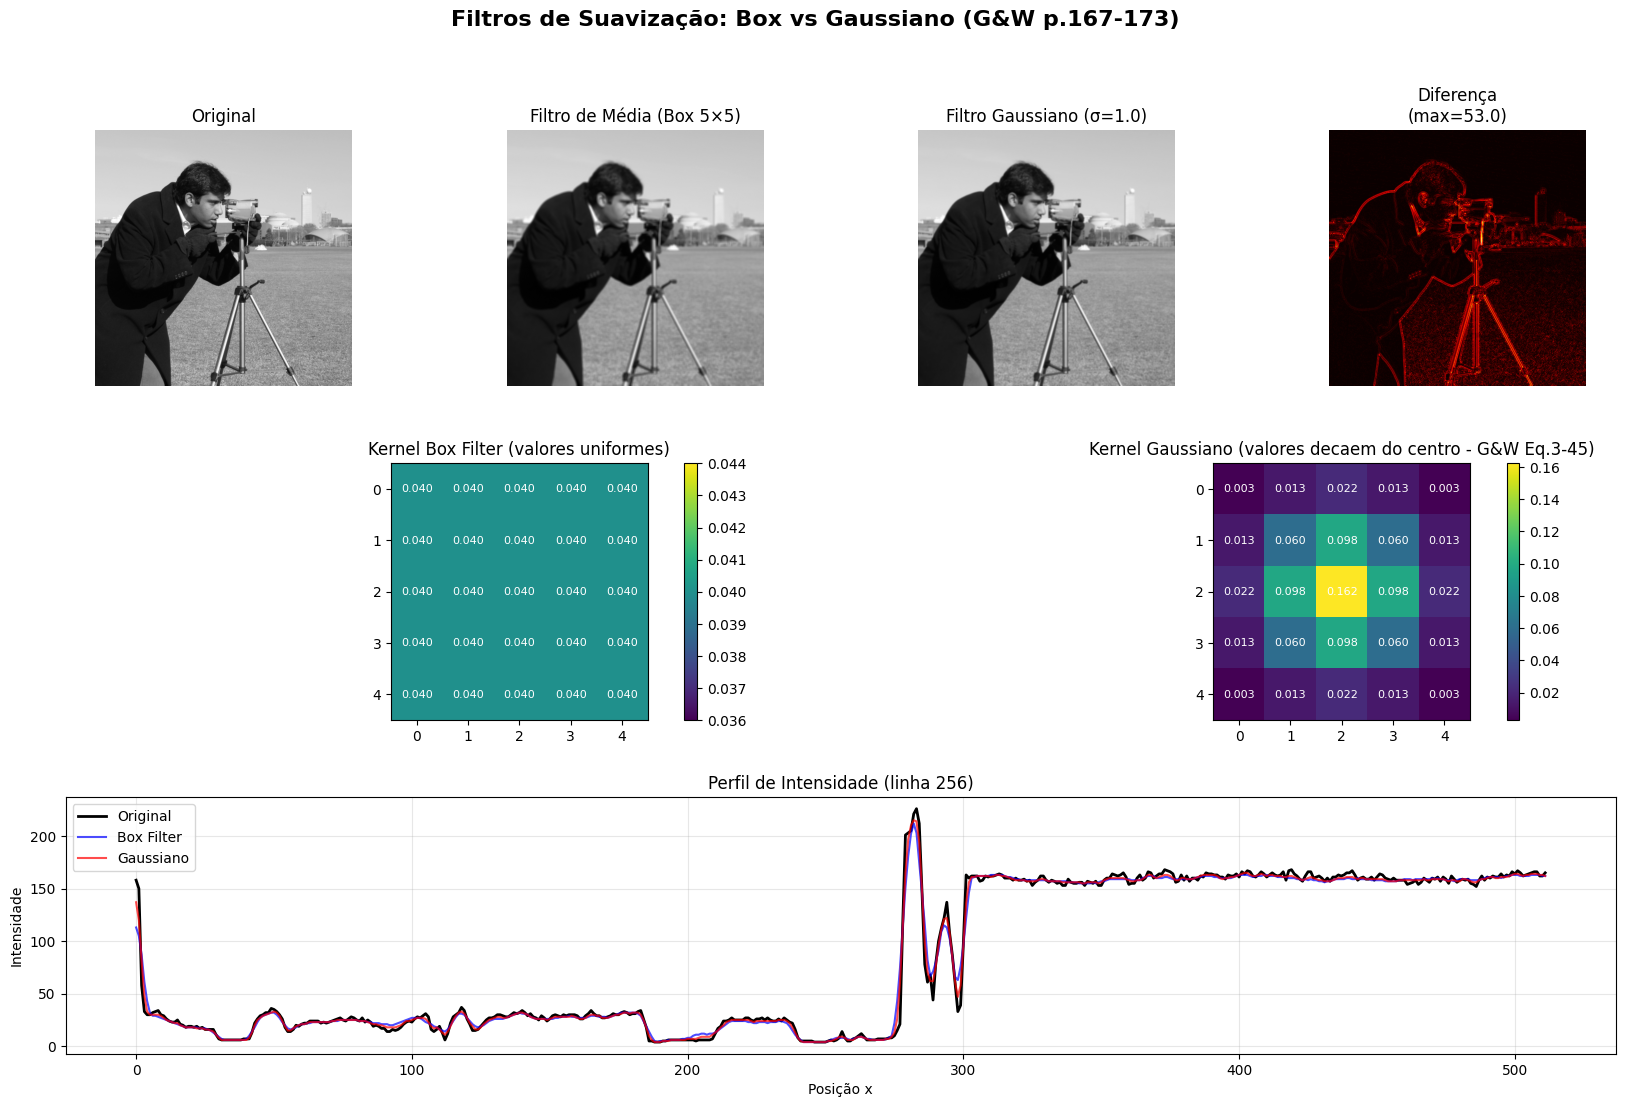


📊 Análise Comparativa:
Box Filter:
  • Transição LINEAR nas bordas (rampa)
  • Todos os pesos são iguais (1/25 = 0.04)
  • Direcionalmente sensível

Gaussiano:
  • Transição SUAVE nas bordas
  • Pesos maiores no centro (isotrópico)
  • Circularmente simétrico
  • Separável (eficiente computacionalmente)

💡 Conclusão (G&W p.171-173):
• Gaussiano é PREFERIDO quando suavização isotrópica é necessária
• Box filter é mais rápido mas produz artefatos direcionais


In [3]:
# 🔬 EXPERIMENTO: Comparação de Filtros de Suavização

print("📊 Comparação: Filtro de Média vs Gaussiano")
print("📚 Referência: Gonzalez & Woods Seção 3.5, p.167-173")
print("=" * 70)

# Carrega imagem
img_original = data.camera()
print(f"Imagem: {img_original.shape}")

# Cria filtros
filtro_box = espacial.filtro_media(tamanho=(5, 5))
filtro_gauss = espacial.filtro_gaussiano(tamanho=(5, 5), sigma=1.0)

print(f"\nKernels criados:")
print(f"• Box filter 5×5 (média uniforme)")
print(f"• Gaussiano 5×5 (σ=1.0)")

# Aplica filtros
img_box = espacial.convolucao_2d(img_original, filtro_box)
img_gauss = espacial.convolucao_2d(img_original, filtro_gauss)

# Garante uint8
img_box = np.clip(img_box, 0, 255).astype(np.uint8)
img_gauss = np.clip(img_gauss, 0, 255).astype(np.uint8)

# Visualização
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Linha 1: Imagens
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_original, cmap='gray')
ax1.set_title("Original")
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(img_box, cmap='gray')
ax2.set_title("Filtro de Média (Box 5×5)")
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(img_gauss, cmap='gray')
ax3.set_title("Filtro Gaussiano (σ=1.0)")
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
diferenca = np.abs(img_box.astype(float) - img_gauss.astype(float))
ax4.imshow(diferenca, cmap='hot')
ax4.set_title(f"Diferença\n(max={diferenca.max():.1f})")
ax4.axis('off')

# Linha 2: Kernels
ax5 = fig.add_subplot(gs[1, 0:2])
im5 = ax5.imshow(filtro_box, cmap='viridis')
ax5.set_title("Kernel Box Filter (valores uniformes)")
plt.colorbar(im5, ax=ax5)
for i in range(5):
    for j in range(5):
        ax5.text(j, i, f'{filtro_box[i,j]:.3f}', ha='center', va='center', color='white', fontsize=8)

ax6 = fig.add_subplot(gs[1, 2:4])
im6 = ax6.imshow(filtro_gauss, cmap='viridis')
ax6.set_title("Kernel Gaussiano (valores decaem do centro - G&W Eq.3-45)")
plt.colorbar(im6, ax=ax6)
for i in range(5):
    for j in range(5):
        ax6.text(j, i, f'{filtro_gauss[i,j]:.3f}', ha='center', va='center', color='white', fontsize=8)

# Linha 3: Perfis de intensidade
linha_central = img_original.shape[0] // 2
perfil_original = img_original[linha_central, :]
perfil_box = img_box[linha_central, :]
perfil_gauss = img_gauss[linha_central, :]

ax7 = fig.add_subplot(gs[2, :])
ax7.plot(perfil_original, 'k-', label='Original', linewidth=2)
ax7.plot(perfil_box, 'b-', label='Box Filter', linewidth=1.5, alpha=0.7)
ax7.plot(perfil_gauss, 'r-', label='Gaussiano', linewidth=1.5, alpha=0.7)
ax7.set_title(f"Perfil de Intensidade (linha {linha_central})")
ax7.set_xlabel("Posição x")
ax7.set_ylabel("Intensidade")
ax7.legend()
ax7.grid(True, alpha=0.3)

plt.suptitle("Filtros de Suavização: Box vs Gaussiano (G&W p.167-173)", fontsize=16, fontweight='bold')
plt.show()

print("\n📊 Análise Comparativa:")
print(f"Box Filter:")
print(f"  • Transição LINEAR nas bordas (rampa)")
print(f"  • Todos os pesos são iguais (1/25 = 0.04)")
print(f"  • Direcionalmente sensível")
print(f"\nGaussiano:")
print(f"  • Transição SUAVE nas bordas")
print(f"  • Pesos maiores no centro (isotrópico)")
print(f"  • Circularmente simétrico")
print(f"  • Separável (eficiente computacionalmente)")

print("\n💡 Conclusão (G&W p.171-173):")
print("• Gaussiano é PREFERIDO quando suavização isotrópica é necessária")
print("• Box filter é mais rápido mas produz artefatos direcionais")

## 5.4 Filtros de Aguçamento (Highpass) - Operadores de Gradiente

### 📚 **Fundamentação Teórica:**

> **Gonzalez & Woods, Seção 3.6, p.179:**  
> "The principal objective of sharpening is to highlight fine detail in an image"

> **Gonzalez & Woods, Cap.10, p.720-722:**  
> "Gradient operators: Sobel, Prewitt - approximate first-order derivatives"

> **Gonzalez & Woods, Eq.10-17:**  
> "Gradient magnitude: |∇f| = √(gₓ² + gᵧ²)"  
> "Direction: θ = arctan(gᵧ/gₓ)"

### 🧮 **Definições Matemáticas:**

#### **1. Operador Sobel:**
```
Gₓ (horizontal):        Gᵧ (vertical):
[-1  0  +1]            [-1 -2 -1]
[-2  0  +2]            [ 0  0  0]
[-1  0  +1]            [+1 +2 +1]
```

#### **2. Operador Prewitt:**
```
Gₓ:                    Gᵧ:
[-1  0  +1]           [-1 -1 -1]
[-1  0  +1]           [ 0  0  0]
[-1  0  +1]           [+1 +1 +1]
```

#### **3. Laplaciano (2ª derivada - G&W Eq.3-51):**
```
∇²f = ∂²f/∂x² + ∂²f/∂y²

Kernel básico:         Kernel diagonal:
[ 0 -1  0]            [-1 -1 -1]
[-1  4 -1]            [-1  8 -1]
[ 0 -1  0]            [-1 -1 -1]
```

### 🎯 **Aplicações (G&W p.179-196):**
- **Edge detection**: Detecção de bordas
- **Image sharpening**: Realce de detalhes finos
- **Feature extraction**: Extração de características

### ⚠️ **Características:**
- **Gradiente (1ª derivada)**: Resposta forte em rampas e degraus
- **Laplaciano (2ª derivada)**: Realce de detalhes finos, MAS sensível a ruído
- **Soma dos coeficientes = 0**: Resposta zero em áreas constantes

---

📐 Operadores de Gradiente: Sobel vs Prewitt
📚 Referência: Gonzalez & Woods Cap.10, p.720-722 + Eq.10-17
✅ Operadores aplicados à imagem (512, 512)

Gradiente magnitude (G&W Eq.10-17):
  |∇f| = √(gₓ² + gᵧ²)


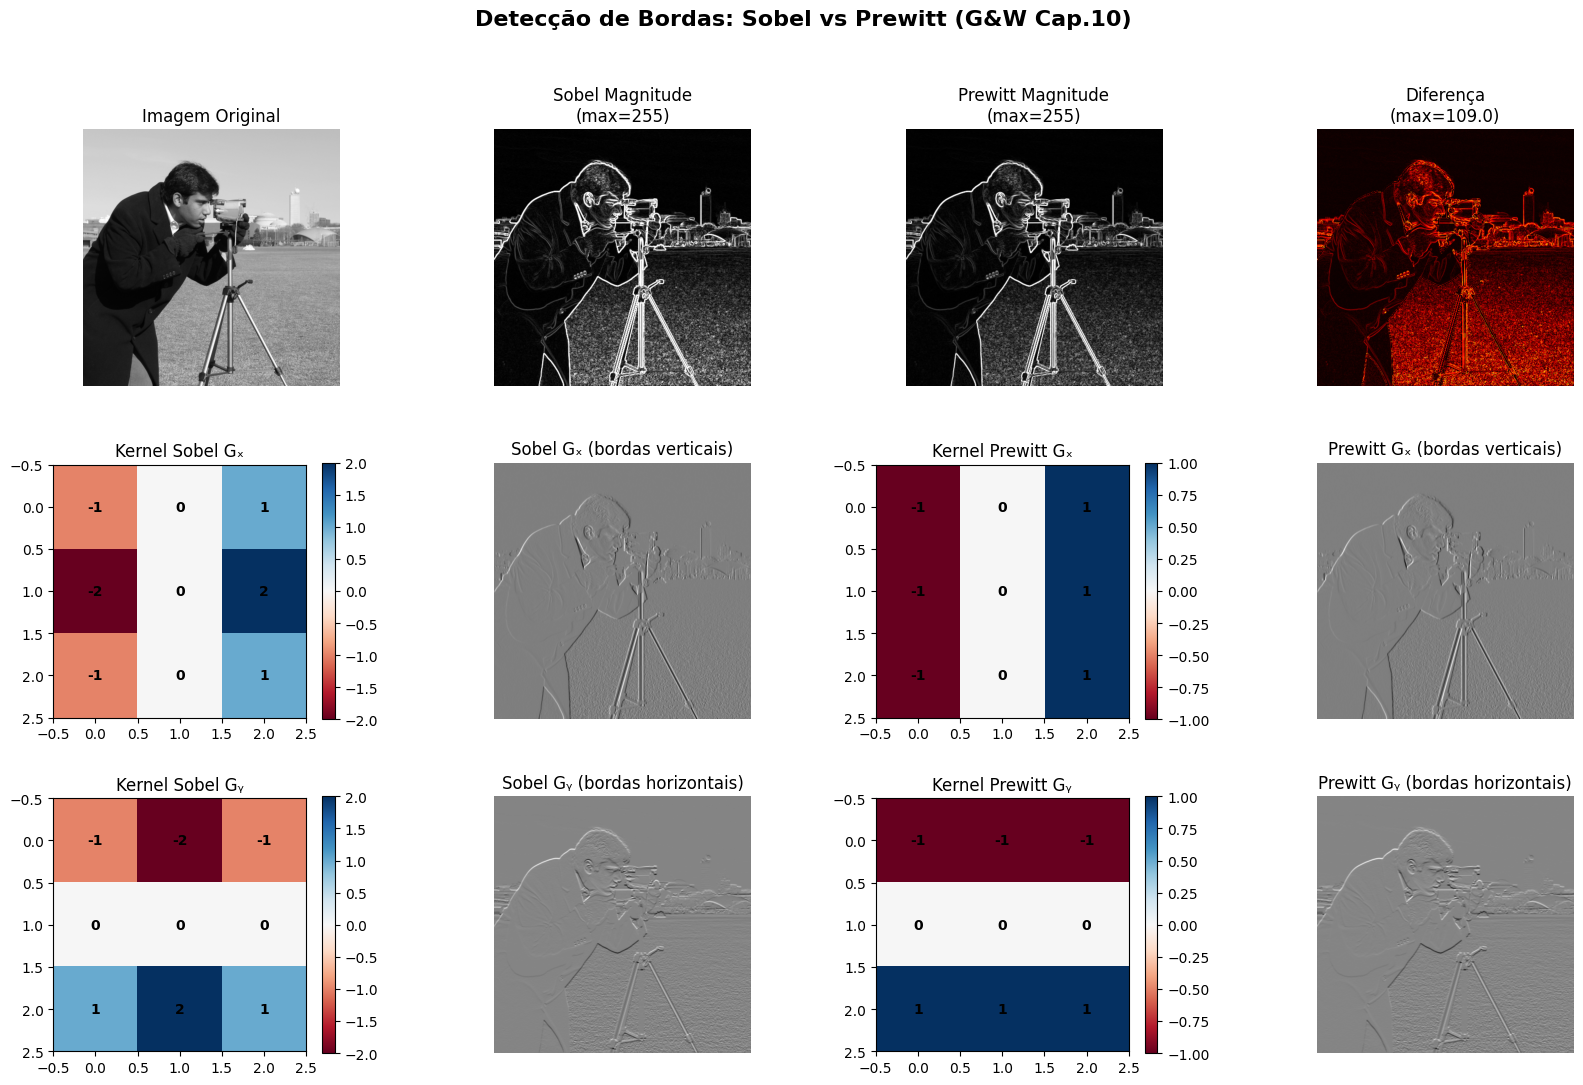


📊 Análise Comparativa:
Sobel:
  • Coeficientes: máximo ±2 (linha central)
  • Maior suavização na direção perpendicular [1 2 1]
  • MENOS sensível a ruído

Prewitt:
  • Coeficientes: uniformes ±1
  • Suavização uniforme [1 1 1]
  • MAIS sensível a ruído

💡 Conclusão (G&W p.722):
• Sobel é PREFERIDO na prática (melhor relação sinal/ruído)
• Diferença é pequena, mas Sobel é mais robusto


In [4]:
# 🔬 EXPERIMENTO: Detecção de Bordas com Operadores de Gradiente

print("📐 Operadores de Gradiente: Sobel vs Prewitt")
print("📚 Referência: Gonzalez & Woods Cap.10, p.720-722 + Eq.10-17")
print("=" * 70)

# Carrega imagem
img = data.camera()

# Aplica operadores Sobel
kernel_sobel_x, kernel_sobel_y = espacial.filtro_sobel(direcao='ambos')
sobel_x = espacial.convolucao_2d(img, kernel_sobel_x)
sobel_y = espacial.convolucao_2d(img, kernel_sobel_y)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

# Aplica operadores Prewitt
kernel_prewitt_x, kernel_prewitt_y = espacial.filtro_prewitt(direcao='ambos')
prewitt_x = espacial.convolucao_2d(img, kernel_prewitt_x)
prewitt_y = espacial.convolucao_2d(img, kernel_prewitt_y)
prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)
prewitt_mag = np.clip(prewitt_mag, 0, 255).astype(np.uint8)

print(f"✅ Operadores aplicados à imagem {img.shape}")
print(f"\nGradiente magnitude (G&W Eq.10-17):")
print(f"  |∇f| = √(gₓ² + gᵧ²)")

# Visualização completa
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Linha 1: Imagem original e magnitudes
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img, cmap='gray')
ax1.set_title("Imagem Original")
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(sobel_mag, cmap='gray')
ax2.set_title(f"Sobel Magnitude\n(max={sobel_mag.max()})")
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(prewitt_mag, cmap='gray')
ax3.set_title(f"Prewitt Magnitude\n(max={prewitt_mag.max()})")
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
diferenca = np.abs(sobel_mag.astype(float) - prewitt_mag.astype(float))
ax4.imshow(diferenca, cmap='hot')
ax4.set_title(f"Diferença\n(max={diferenca.max():.1f})")
ax4.axis('off')

# Linha 2: Gradientes horizontais (Gx)
ax5 = fig.add_subplot(gs[1, 0])
im5 = ax5.imshow(kernel_sobel_x, cmap='RdBu', vmin=-2, vmax=2)
ax5.set_title("Kernel Sobel Gₓ")
plt.colorbar(im5, ax=ax5)
for i in range(3):
    for j in range(3):
        ax5.text(j, i, f'{kernel_sobel_x[i,j]:.0f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax6 = fig.add_subplot(gs[1, 1])
ax6.imshow(sobel_x, cmap='gray')
ax6.set_title("Sobel Gₓ (bordas verticais)")
ax6.axis('off')

ax7 = fig.add_subplot(gs[1, 2])
im7 = ax7.imshow(kernel_prewitt_x, cmap='RdBu', vmin=-1, vmax=1)
ax7.set_title("Kernel Prewitt Gₓ")
plt.colorbar(im7, ax=ax7)
for i in range(3):
    for j in range(3):
        ax7.text(j, i, f'{kernel_prewitt_x[i,j]:.0f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax8 = fig.add_subplot(gs[1, 3])
ax8.imshow(prewitt_x, cmap='gray')
ax8.set_title("Prewitt Gₓ (bordas verticais)")
ax8.axis('off')

# Linha 3: Gradientes verticais (Gy)
ax9 = fig.add_subplot(gs[2, 0])
im9 = ax9.imshow(kernel_sobel_y, cmap='RdBu', vmin=-2, vmax=2)
ax9.set_title("Kernel Sobel Gᵧ")
plt.colorbar(im9, ax=ax9)
for i in range(3):
    for j in range(3):
        ax9.text(j, i, f'{kernel_sobel_y[i,j]:.0f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax10 = fig.add_subplot(gs[2, 1])
ax10.imshow(sobel_y, cmap='gray')
ax10.set_title("Sobel Gᵧ (bordas horizontais)")
ax10.axis('off')

ax11 = fig.add_subplot(gs[2, 2])
im11 = ax11.imshow(kernel_prewitt_y, cmap='RdBu', vmin=-1, vmax=1)
ax11.set_title("Kernel Prewitt Gᵧ")
plt.colorbar(im11, ax=ax11)
for i in range(3):
    for j in range(3):
        ax11.text(j, i, f'{kernel_prewitt_y[i,j]:.0f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax12 = fig.add_subplot(gs[2, 3])
ax12.imshow(prewitt_y, cmap='gray')
ax12.set_title("Prewitt Gᵧ (bordas horizontais)")
ax12.axis('off')

plt.suptitle("Detecção de Bordas: Sobel vs Prewitt (G&W Cap.10)", fontsize=16, fontweight='bold')
plt.show()

print("\n📊 Análise Comparativa:")
print(f"Sobel:")
print(f"  • Coeficientes: máximo ±2 (linha central)")
print(f"  • Maior suavização na direção perpendicular [1 2 1]")
print(f"  • MENOS sensível a ruído")
print(f"\nPrewitt:")
print(f"  • Coeficientes: uniformes ±1")
print(f"  • Suavização uniforme [1 1 1]")
print(f"  • MAIS sensível a ruído")

print("\n💡 Conclusão (G&W p.722):")
print("• Sobel é PREFERIDO na prática (melhor relação sinal/ruído)")
print("• Diferença é pequena, mas Sobel é mais robusto")

## 5.5 Filtro Laplaciano e Unsharp Masking

### 📚 **Fundamentação Teórica:**

> **Gonzalez & Woods, Eq.3-51, p.182:**  
> "Laplacian: ∇²f = ∂²f/∂x² + ∂²f/∂y²"  
> "The Laplacian is a second-order derivative operator"

> **Gonzalez & Woods, Eq.3-58, p.186:**  
> "Unsharp masking: g(x,y) = f(x,y) + k × ∇²f(x,y)"  
> "Used extensively in the printing and publishing industry for sharpening"

### 🧮 **Definições Matemáticas:**

#### **Laplaciano Isotrópico (G&W p.182):**
```
∇²f = [f(x+1,y) + f(x-1,y) + f(x,y+1) + f(x,y-1)] - 4f(x,y)

Kernel básico:           Kernel com diagonais:
    [ 0 -1  0]              [-1 -1 -1]
    [-1  4 -1]              [-1  8 -1]
    [ 0 -1  0]              [-1 -1 -1]
```

#### **Unsharp Masking (G&W Eq.3-58):**
```
1. Desfoque: fₛ(x,y) = Gaussiana ⊛ f(x,y)
2. Máscara: máscara(x,y) = f(x,y) - fₛ(x,y)
3. Realce: g(x,y) = f(x,y) + k × máscara(x,y)
```

### 🎯 **Aplicações (G&W p.182-186):**
- **Image sharpening**: Realce de bordas e detalhes finos
- **Edge enhancement**: Melhorar transições
- **Medical imaging**: Realce de estruturas sutis

### 🔢 **Parâmetros Típicos:**
- **k (peso)**: 0.2 a 1.0 (controla intensidade do realce)
- **σ (blur)**: 1.0 a 3.0 (tamanho da máscara)

### ⚠️ **Cuidados:**
- Laplaciano é **muito sensível a ruído** (2ª derivada)
- **Amplifica ruído**: suavização prévia é recomendada
- Soma dos coeficientes = 0 (resposta zero em regiões constantes)

---

🔍 Aguçamento com Laplaciano e Unsharp Masking
📚 Referência: Gonzalez & Woods Eq.3-51 (p.182) e Eq.3-58 (p.186)
Imagem: (512, 512)

✅ Filtros aplicados:
  • Laplaciano básico (4-conectado)
  • Laplaciano diagonal (8-conectado)
  • Unsharp masking (σ=1.0, k=0.8)


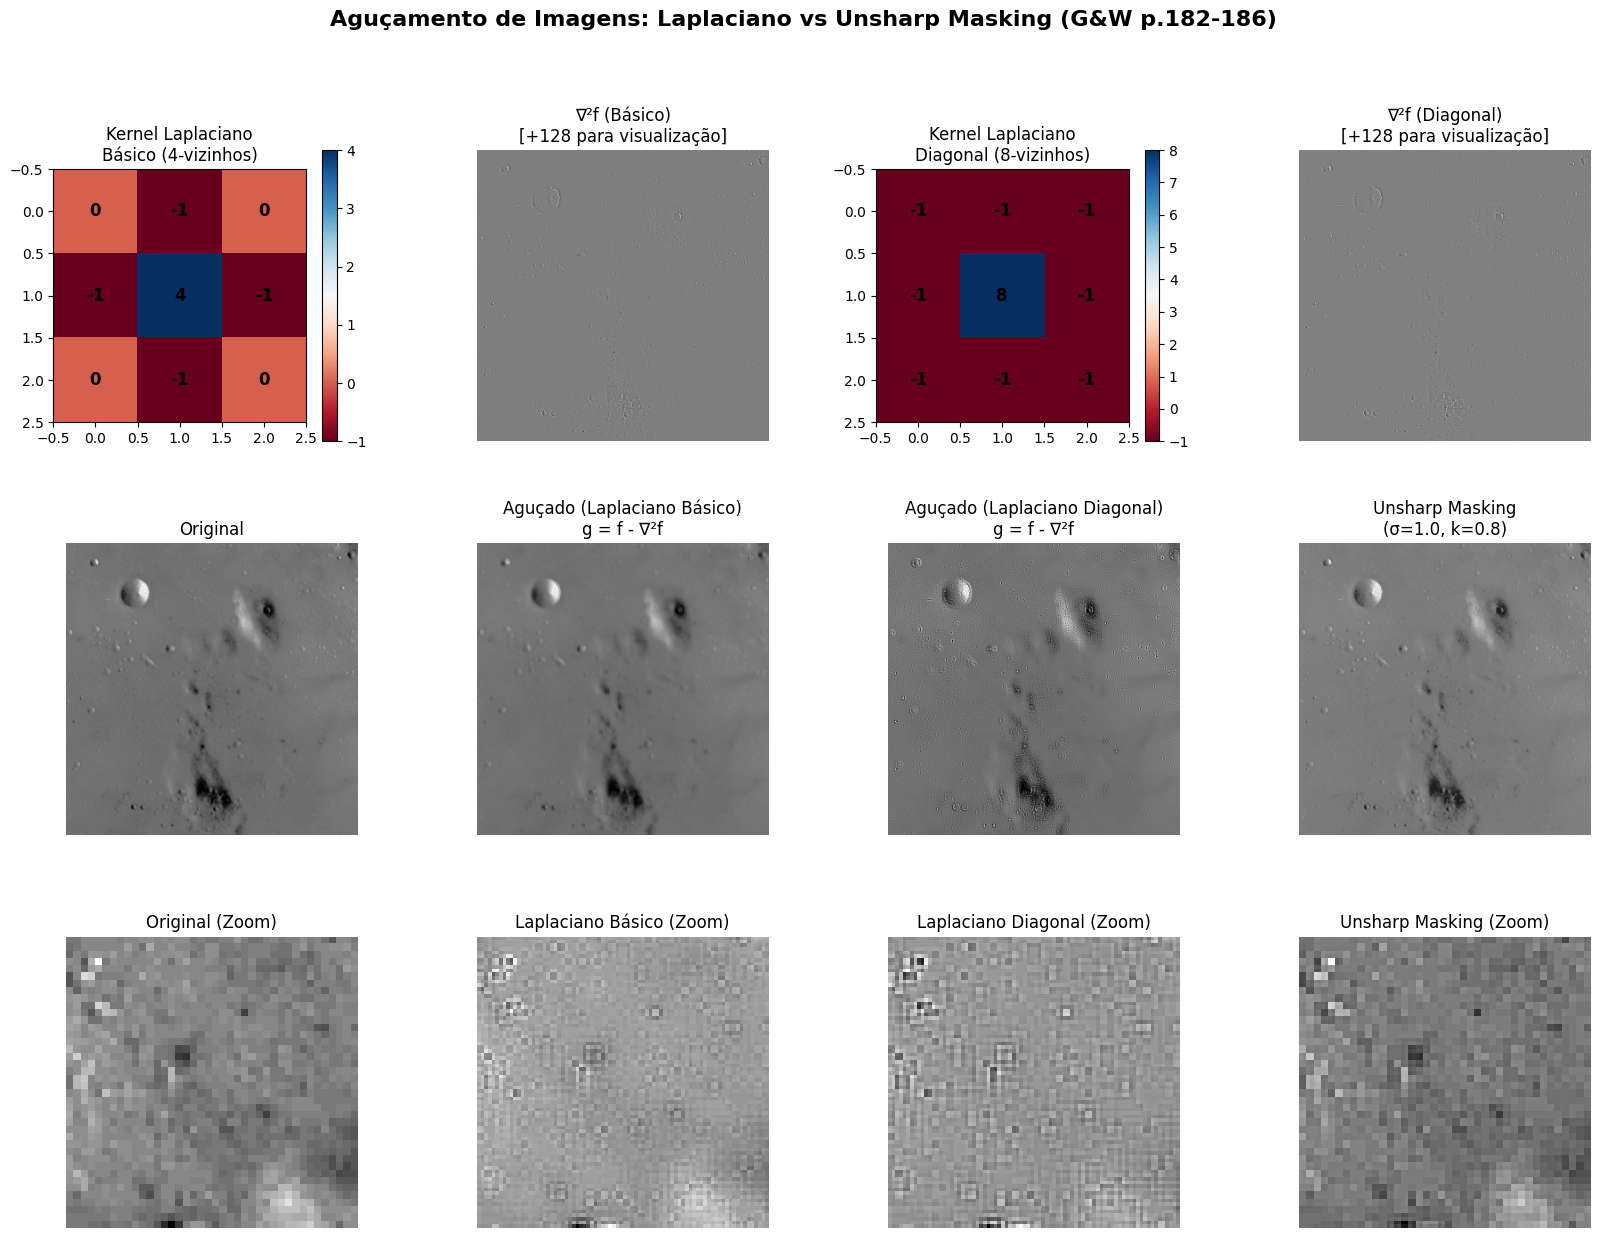


📊 Análise Comparativa:
Laplaciano Básico (4-vizinhos):
  • Realça bordas horizontais/verticais
  • Menos sensível a ruído diagonal

Laplaciano Diagonal (8-vizinhos):
  • Realça todas as direções uniformemente
  • Isotrópico (circularmente simétrico)
  • MAIS sensível a ruído

Unsharp Masking:
  • Controle fino da intensidade (parâmetro k)
  • Suavização prévia reduz ruído
  • PREFERIDO na prática profissional

💡 Conclusão (G&W p.186):
• Unsharp masking é mais robusto que Laplaciano direto
• Permite controle preciso do aguçamento
• Usado extensivamente em impressão e publicação


In [5]:
# 🔬 EXPERIMENTO: Laplaciano e Unsharp Masking

print("🔍 Aguçamento com Laplaciano e Unsharp Masking")
print("📚 Referência: Gonzalez & Woods Eq.3-51 (p.182) e Eq.3-58 (p.186)")
print("=" * 70)

# Carrega imagem
img = data.moon()
print(f"Imagem: {img.shape}")

# 1. Laplaciano básico
kernel_lap_basico = espacial.filtro_laplaciano(tipo='basico')
kernel_lap_diagonal = espacial.filtro_laplaciano(tipo='diagonal')

laplaciano_basico = espacial.convolucao_2d(img, kernel_lap_basico)
laplaciano_diagonal = espacial.convolucao_2d(img, kernel_lap_diagonal)

# Aguçamento com Laplaciano (G&W Eq.3-58: g = f + k*∇²f)
k = 0.5
img_agucada_basico = img.astype(float) - laplaciano_basico  # kernel negativo
img_agucada_diagonal = img.astype(float) - laplaciano_diagonal

img_agucada_basico = np.clip(img_agucada_basico, 0, 255).astype(np.uint8)
img_agucada_diagonal = np.clip(img_agucada_diagonal, 0, 255).astype(np.uint8)

# 2. Unsharp Masking
img_unsharp = espacial.unsharp_masking(img, sigma=1.0, quantidade=0.8)

print(f"\n✅ Filtros aplicados:")
print(f"  • Laplaciano básico (4-conectado)")
print(f"  • Laplaciano diagonal (8-conectado)")
print(f"  • Unsharp masking (σ=1.0, k=0.8)")

# Visualização
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Linha 1: Kernels e resultados Laplaciano
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(kernel_lap_basico, cmap='RdBu', vmin=-1, vmax=4)
ax1.set_title("Kernel Laplaciano\nBásico (4-vizinhos)")
plt.colorbar(im1, ax=ax1)
for i in range(3):
    for j in range(3):
        ax1.text(j, i, f'{kernel_lap_basico[i,j]:.0f}', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(laplaciano_basico + 128, cmap='gray')  # +128 para visualização
ax2.set_title("∇²f (Básico)\n[+128 para visualização]")
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(kernel_lap_diagonal, cmap='RdBu', vmin=-1, vmax=8)
ax3.set_title("Kernel Laplaciano\nDiagonal (8-vizinhos)")
plt.colorbar(im3, ax=ax3)
for i in range(3):
    for j in range(3):
        ax3.text(j, i, f'{kernel_lap_diagonal[i,j]:.0f}', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(laplaciano_diagonal + 128, cmap='gray')
ax4.set_title("∇²f (Diagonal)\n[+128 para visualização]")
ax4.axis('off')

# Linha 2: Resultados de aguçamento
ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(img, cmap='gray')
ax5.set_title("Original")
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 1])
ax6.imshow(img_agucada_basico, cmap='gray')
ax6.set_title("Aguçado (Laplaciano Básico)\ng = f - ∇²f")
ax6.axis('off')

ax7 = fig.add_subplot(gs[1, 2])
ax7.imshow(img_agucada_diagonal, cmap='gray')
ax7.set_title("Aguçado (Laplaciano Diagonal)\ng = f - ∇²f")
ax7.axis('off')

ax8 = fig.add_subplot(gs[1, 3])
ax8.imshow(img_unsharp, cmap='gray')
ax8.set_title("Unsharp Masking\n(σ=1.0, k=0.8)")
ax8.axis('off')

# Linha 3: Zoom comparativo
roi_y, roi_x = 100, 150  # Região de interesse
roi_size = 80

ax9 = fig.add_subplot(gs[2, 0])
roi_original = img[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
ax9.imshow(roi_original, cmap='gray')
ax9.set_title("Original (Zoom)")
ax9.axis('off')

ax10 = fig.add_subplot(gs[2, 1])
roi_basico = img_agucada_basico[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
ax10.imshow(roi_basico, cmap='gray')
ax10.set_title("Laplaciano Básico (Zoom)")
ax10.axis('off')

ax11 = fig.add_subplot(gs[2, 2])
roi_diagonal = img_agucada_diagonal[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
ax11.imshow(roi_diagonal, cmap='gray')
ax11.set_title("Laplaciano Diagonal (Zoom)")
ax11.axis('off')

ax12 = fig.add_subplot(gs[2, 3])
roi_unsharp = img_unsharp[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
ax12.imshow(roi_unsharp, cmap='gray')
ax12.set_title("Unsharp Masking (Zoom)")
ax12.axis('off')

plt.suptitle("Aguçamento de Imagens: Laplaciano vs Unsharp Masking (G&W p.182-186)", fontsize=16, fontweight='bold')
plt.show()

print("\n📊 Análise Comparativa:")
print(f"Laplaciano Básico (4-vizinhos):")
print(f"  • Realça bordas horizontais/verticais")
print(f"  • Menos sensível a ruído diagonal")
print(f"\nLaplaciano Diagonal (8-vizinhos):")
print(f"  • Realça todas as direções uniformemente")
print(f"  • Isotrópico (circularmente simétrico)")
print(f"  • MAIS sensível a ruído")
print(f"\nUnsharp Masking:")
print(f"  • Controle fino da intensidade (parâmetro k)")
print(f"  • Suavização prévia reduz ruído")
print(f"  • PREFERIDO na prática profissional")

print("\n💡 Conclusão (G&W p.186):")
print("• Unsharp masking é mais robusto que Laplaciano direto")
print("• Permite controle preciso do aguçamento")
print("• Usado extensivamente em impressão e publicação")

## 📊 Resumo Final e Conclusões

### 🎯 **O que Aprendemos:**

Neste notebook, exploramos **filtragem espacial**, uma das operações mais fundamentais em processamento de imagens.

#### **1. Conceitos Fundamentais:**
- **Convolução 2D** (Gonzalez & Woods Eq.3-35): Operação base para filtros lineares
- **Diferença entre convolução e correlação**: Rotação de 180° do kernel
- **Propriedades**: Comutatividade, associatividade, distributividade

#### **2. Filtros de Suavização (Lowpass):**
- **Filtro de Média (Box)**: Simples mas com artefatos direcionais
- **Filtro Gaussiano** (G&W Eq.3-45): Preferido por ser isotrópico e separável
- **Aplicações**: Redução de ruído, desfoque, pré-processamento

#### **3. Filtros de Aguçamento (Highpass):**
- **Gradiente (1ª derivada)**: Sobel e Prewitt para detecção de bordas
- **Laplaciano (2ª derivada)** (G&W Eq.3-51): Realce de detalhes finos
- **Unsharp Masking** (G&W Eq.3-58): Método profissional de aguçamento

---

### 📚 **Referências Acadêmicas Principais:**

**Gonzalez & Woods, Digital Image Processing 4e:**
- **Eq.3-35 (p.159)**: Convolução 2D - fundamento de filtros lineares
- **Eq.3-45 (p.169)**: Filtro Gaussiano - suavização isotrópica
- **Eq.3-51 (p.182)**: Laplaciano - 2ª derivada para detecção de detalhes
- **Eq.3-58 (p.186)**: Unsharp masking - aguçamento controlado
- **Cap.10 (p.720-722)**: Operadores de gradiente (Sobel, Prewitt)

---

### 💡 **Principais Conclusões:**

1. **Suavização**: Gaussiano é superior ao Box filter (isotrópico, separável)
2. **Detecção de bordas**: Sobel é preferido ao Prewitt (menos sensível a ruído)
3. **Aguçamento**: Unsharp masking é mais robusto que Laplaciano direto
4. **Trade-off fundamental**: Suavização reduz ruído MAS também reduz detalhes
5. **Segunda derivada**: Mais sensível a ruído que primeira derivada

---

### 🔜 **Próximos Passos:**

No próximo notebook, exploraremos:
- **Filtragem na Frequência**: Transformada de Fourier 2D
- **Filtros no domínio da frequência**: Passa-baixa, passa-alta, passa-banda
- **Teorema da Convolução**: Multiplicação no domínio da frequência

---

**📖 Estudo completo!** Este notebook cobriu os fundamentos de filtragem espacial com implementações manuais e referências acadêmicas completas.